## 0. Libraries and mount

In [1]:
from google.colab import drive
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import plotly.graph_objects as go
import numpy as np
import math

drive.mount('/content/drive')

Mounted at /content/drive


## 1. Classes
* Label the colors of the boxes.
* The next step is to modularize the heuristic, giving the input boxes and the position of the box at the output.

Packages

In [2]:
class Package:
  def __init__(self, id, length, width, height, stack, color, weight=0):
    self.id = id
    self.length = length
    self.width = width
    self.height = height
    self.weight = weight
    self.stackability = stack
    self.area2d = width * length
    self.area3d = height * width * length
    self.quantity = 1
    self.color = color

class allPackages:
  def __init__(self):
    self.packages = []
    self.num_packages = 0
    self.total_2darea = 0
    self.total_3darea = 0
    self.total_2d_area_stacked = 0

  def addPackage(self, id, length, width, height, stack, color, weight):
    qtd_increase = 0
    for package in self.packages:
      if package.id ==  id:
        package.quantity += 1
        qtd_increase = 1
    if qtd_increase == 0:
      self.packages.append(Package(id, length, width, height, stack, color, weight))
    self.num_packages += 1
    self.total_2darea += (length * width)
    self.total_3darea += (length * width * height)

  def showPackages(self):
    for p in self.packages:
      print(f'ID: {p.id}, length:{p.length}, width:{p.width}, height:{p.height}, stackability:{p.stackability}, area2d:{p.area2d}, quantity:{p.quantity}, color:{p.color}, weight:{p.weight}')

Trucks

In [3]:
class Truck:
  def __init__(self, id, length, width, height, capacity_weight = 0):
    self.id = id
    self.length = length
    self.width = width
    self.height = height
    self.capacity_area2d = length * width
    self.capacity_area3d = length * width * height
    self.capacity_weight = capacity_weight
    self.ocupated_area = 0
    self.total_packages_weight = 0
    self.packages = []
    self.occupied = []
    self.placements = []

  def plot_truck_configuration(self):
    rect_dimensions = self.occupied
    rect_positions = self.placements
    fig, ax = plt.subplots()

    rect_x, rect_y = 0, 0
    rect_width, rect_length = self.width, self.length
    rectangle = patches.Rectangle((rect_x, rect_y), rect_width, rect_length,
                                    linewidth=2, edgecolor='black', facecolor='#4169E1')
    ax.add_patch(rectangle)

    cont_stack = 0
    for i in range(len(rect_dimensions)):
      square = patches.Rectangle((rect_dimensions[i][0], rect_dimensions[i][1]), rect_dimensions[i][2] - rect_dimensions[i][0], rect_dimensions[i][3] - rect_dimensions[i][1],
                                          linewidth=0.1, edgecolor='white', facecolor=self.packages[i].color)
      ax.add_patch(square)
      cont_stack += 1

      if i > 0 and rect_positions[i] != rect_positions[i - 1]:
        center_x = rect_positions[i - 1][0] + self.packages[i - 1].width / 2
        center_y = rect_positions[i - 1][1] + self.packages[i - 1].height / 2
        label = str(cont_stack - 1)
        ax.text(center_x, center_y, label,
                color='black', fontsize=12, ha='center', va='center')
        cont_stack = 1
      elif i == len(rect_dimensions) - 1    :
        center_x = rect_positions[i][0] + self.packages[i].width / 2
        center_y = rect_positions[i][1] + self.packages[i].height / 2
        label = str(cont_stack)
        ax.text(center_x, center_y, label,
                color='black', fontsize=12, ha='center', va='center')

    pad = 500
    ax.set_xlim(-pad, rect_width + pad)
    ax.set_ylim(-pad, rect_length + pad)
    ax.set_aspect('equal')
    plt.show()

In [4]:
class all_trucks:
  def __init__(self):
    self.trucks = []
    self.num_trucks = 0
    self.truck_measures = []
    self.truck_weight_capacities = []

  def no_collision(self, list_of_boxes, new_box, truck_dims):
    if new_box[2] > truck_dims[0] or new_box[3] > truck_dims[1]:
      return False
    for b in list_of_boxes:
      if not(b[2] <= new_box[0] or b[0] >= new_box[2] or
             b[3] <= new_box[1] or b[1] >= new_box[3]):
        return False
    return True

  def position_avaliable_lower_left(self, truck:Truck, box:Package):
    for i in range(truck.width - 1):
      for j in range(truck.length - 1):
        new_rect = (i, j, i + box.width, j + box.length)

        if self.no_collision(truck.occupied, new_rect, (truck.width, truck.length)) == True:
          return (i, j)

    return (-1, -1)

  def alocate_box(self, truck: Truck, box: Package, box_position, stacking=0):
    truck.placements.append(box_position)
    truck.occupied.append((box_position[0], box_position[1],
                           box_position[0] + box.width, box_position[1] + box.length))
    truck.packages.append(box)
    if stacking == 0:
      truck.ocupated_area += box.area2d

  def decide_capacity(self, area_left):
    for measures in self.truck_measures:
      if measures[0] * measures[1] > area_left:
        return measures
    return self.truck_measures[-1]

  def add_truck(self, id_t, length_t, width_t, height_t, capacity_weight=0):
    if length_t == 13600 and width_t == 2400:
      capacity_weight = 26000
    elif length_t == 9000 and width_t == 2400 and height_t==2600:
      capacity_weight = 15000

    self.trucks.append(Truck(id_t, length_t, width_t, height_t, capacity_weight))
    self.num_trucks += 1

  def add_package(self, pack: Package, pack_area_left, stack=0, stack_pos=(-1, -1)):
    if stack == 0:
      if self.num_trucks == 0 or self.trucks[self.num_trucks - 1].ocupated_area + pack.area2d > self.trucks[self.num_trucks - 1].capacity_area2d:
        measurements = self.decide_capacity(pack_area_left)
        self.add_truck(self.num_trucks + 1, measurements[0], measurements[1], measurements[2])

      box_pos = self.position_avaliable_lower_left(self.trucks[self.num_trucks - 1], pack)
      if box_pos != (-1, -1):
        self.alocate_box(self.trucks[self.num_trucks - 1], pack, box_pos)
        return box_pos
      else:
        measurements = self.decide_capacity(pack_area_left)
        self.add_truck(self.num_trucks + 1, measurements[0], measurements[1], measurements[2])
        self.alocate_box(self.trucks[self.num_trucks - 1], pack, (0, 0))
        return (0, 0)

    else:
      self.alocate_box(self.trucks[self.num_trucks - 1], pack, stack_pos, 1)
      return stack_pos

##2. Loading files

Opening JSON

In [5]:
arq = '/content/drive/MyDrive/truck_loading/'

with open(arq + 'containers_2.json') as f:
  containers = json.load(f)
with open(arq + 'quantities_2.json') as f:
  quantities = json.load(f)
with open(arq + 'trucks_2.json') as f:
  trucks = json.load(f)

Loading package types into the structure

In [6]:
quantitiesOfDiferentPackages = {}

for quant in quantities:
  if quant['code'] in quantitiesOfDiferentPackages.keys():
    quantitiesOfDiferentPackages[quant['code']] += quant['quantity']
  else:
    quantitiesOfDiferentPackages[quant['code']] = quant['quantity']

In [7]:
packages = allPackages()

aux_pack = []
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#0082c8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#d2f53c", "#fabebe",
    "#008080", "#e6beff", "#aa6e28", "#fffac8", "#800000",
    "#aaffc3", "#808000", "#ffd8b1", "#000080", "#808080"]

c_cont = 0
total_2d_area_stacked = 0
for cont in containers:
  for pack_numb in range(quantitiesOfDiferentPackages[cont['code']]):
    aux_pack.append([cont['code'], cont['length'], cont['width'], cont['height'], cont['stackability'], colors[c_cont], cont['weight']])
  total_2d_area_stacked += cont['length'] * cont['width'] * math.ceil((quantitiesOfDiferentPackages[cont['code']]/cont['stackability']))
  c_cont += 1

packages.total_2d_area_stacked = total_2d_area_stacked

for a_p in aux_pack:
  packages.addPackage(id=a_p[0], length=a_p[1], width=a_p[2], height=a_p[3], stack=a_p[4], color=a_p[5], weight=a_p[6])

packages.showPackages()

ID: 1235, length:2000, width:1200, height:500, stackability:3, area2d:2400000, quantity:17, color:#e6194b, weight:529.4
ID: 4888, length:1450, width:1100, height:780, stackability:3, area2d:1595000, quantity:24, color:#3cb44b, weight:447.3
ID: 7465, length:1650, width:800, height:1050, stackability:2, area2d:1320000, quantity:6, color:#ffe119, weight:732.8
ID: 7466, length:1650, width:800, height:1050, stackability:2, area2d:1320000, quantity:6, color:#0082c8, weight:732.8
ID: 7897, length:2200, width:1100, height:650, stackability:3, area2d:2420000, quantity:10, color:#f58231, weight:1130
ID: 7915, length:1500, width:1200, height:1210, stackability:2, area2d:1800000, quantity:12, color:#911eb4, weight:354.7
ID: 8589, length:1600, width:1200, height:500, stackability:3, area2d:1920000, quantity:2, color:#46f0f0, weight:935.5
ID: 8589.2, length:1450, width:1100, height:780, stackability:3, area2d:1595000, quantity:2, color:#f032e6, weight:1471
ID: 8646, length:2400, width:1200, height:1

Loading truck types.

In [8]:
vehicles = all_trucks()

for t in trucks:
  vehicles.truck_measures.append([int(t['length']), int(t['width']), int(t['height'])])

vehicles.truck_measures.sort(key=lambda a : a[0]*a[1]*a[2])

vehicles.truck_measures

[[9000, 2400, 2600], [13600, 2400, 2800], [13600, 2400, 3000]]

##3. Filling the trucks by stacking the boxes

In [9]:
remaining_packages = packages.num_packages
remaining_area = packages.total_2d_area_stacked


for p in packages.packages:
  cont = 0
  while cont < p.quantity:
    pos_alocated = vehicles.add_package(p, remaining_area, 0, (-1, -1))
    remaining_area -= p.area2d
    vehicles.trucks[-1].total_packages_weight += p.weight
    remaining_packages -= 1
    cont += 1

    stacked_now = 1
    height_now = p.height
    while stacked_now < p.stackability and cont < p.quantity:
      vehicles.add_package(p, remaining_area, 1, pos_alocated)
      vehicles.trucks[-1].total_packages_weight += p.weight
      remaining_packages -= 1
      cont += 1
      height_now += p.height

      stacked_now += 1
    stacked_now = 0

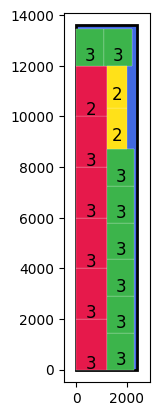

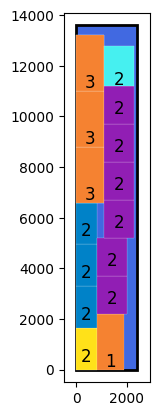

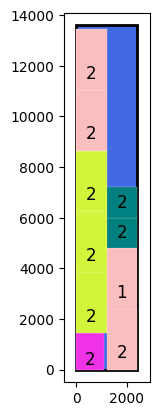

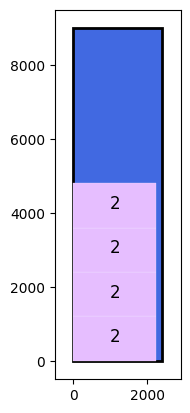

In [ ]:
max_height = 0
for i in range(vehicles.num_trucks):
  for j in range(len(vehicles.trucks[i].packages)):
    height_now = 0
    for k in range(vehicles.trucks[i].packages[i].stackability):
      height_now += vehicles.trucks[i].packages[i].height

    if height_now > max_height:
      max_height = height_now

  if max_height <= vehicles.trucks[i].height and (vehicles.trucks[i].length == 13600 and vehicles.trucks[i].width == 2400 and vehicles.trucks[i].height == 3000):
    vehicles.trucks[i].height = 2800

for i in range(vehicles.num_trucks):
  vehicles.trucks[i].plot_truck_configuration()

## 4. Generating trucks in 3D

In [ ]:
import numpy as np
import plotly.graph_objects as go

def create_cube(x, y, z, dx, dy, dz, color='blue', number='1'):
    v = np.array([
        [x,     y,     z],
        [x+dx,  y,     z],
        [x+dx,  y+dy,  z],
        [x,     y+dy,  z],
        [x,     y,     z+dz],
        [x+dx,  y,     z+dz],
        [x+dx,  y+dy,  z+dz],
        [x,     y+dy,  z+dz]
    ])
    f = np.array([
        [0,1,2,3], [4,5,6,7],
        [0,1,5,4], [2,3,7,6],
        [1,2,6,5], [3,0,4,7]
    ])
    x_vals, y_vals, z_vals, I, J, K = [], [], [], [], [], []
    for face in f:
        idx = len(x_vals)
        for vert in face:
            x_vals.append(v[vert,0])
            y_vals.append(v[vert,1])
            z_vals.append(v[vert,2])
        I += [idx, idx]
        J += [idx+1, idx+2]
        K += [idx+2, idx+3]

    cube_mesh = go.Mesh3d(
        x=x_vals, y=y_vals, z=z_vals,
        i=I, j=J, k=K,
        color=color, opacity=1
    )

    edges = [
        (0,1), (1,2), (2,3), (3,0),
        (4,5), (5,6), (6,7), (7,4),
        (0,4), (1,5), (2,6), (3,7)
    ]
    x_lines, y_lines, z_lines = [], [], []
    for start, end in edges:
        x_lines += [v[start][0], v[end][0], None]
        y_lines += [v[start][1], v[end][1], None]
        z_lines += [v[start][2], v[end][2], None]

    cube_edges = go.Scatter3d(
        x=x_lines,
        y=y_lines,
        z=z_lines,
        mode='lines',
        line=dict(color='black', width=5),
        showlegend=False
    )

    top_face_center = np.mean(v[4:8], axis=0)

    cube_label = go.Scatter3d(
        x=[top_face_center[0]],
        y=[top_face_center[1]],
        z=[top_face_center[2] + dz * 0.2],
        mode='text',
        text=[number],
        textposition="middle center",
        textfont=dict(size=10, color='black'),
        showlegend=False
    )

    return [cube_mesh, cube_edges, cube_label]

In [ ]:
name = {2800: 'Mega Truck',
        3000: 'Mega High Truck',
        2600: 'Tractor'}

In [ ]:
for truck_number in range(vehicles.num_trucks):
  truck_length = vehicles.trucks[truck_number].width
  truck_width  = vehicles.trucks[truck_number].length
  truck_height = vehicles.trucks[truck_number].height

  if vehicles.trucks[truck_number].total_packages_weight < vehicles.trucks[truck_number].capacity_weight * 0.7:
    color_weight = 'blue'
  elif vehicles.trucks[truck_number].total_packages_weight < vehicles.trucks[truck_number].capacity_weight * 0.9:
    color_weight = 'green'
  elif vehicles.trucks[truck_number].total_packages_weight < vehicles.trucks[truck_number].capacity_weight:
    color_weight = 'goldenrod'
  else:
    color_weight = 'red'

  truck, _, _ = create_cube(0, 0, 0, truck_length, truck_width, truck_height,color='royalblue')
  truck.opacity = 0.2

  fig = go.Figure()
  fig.add_trace(truck)

  boxes_2d = []
  heights = []
  z_cursors = []

  altura_caixa = 0
  for i in range(len(vehicles.trucks[truck_number].occupied)):
    boxes_2d.append(vehicles.trucks[truck_number].occupied[i])
    heights.append(vehicles.trucks[truck_number].packages[i].height)

    if i > 0 and vehicles.trucks[truck_number].occupied[i] == vehicles.trucks[truck_number].occupied[i-1]:
      altura_caixa += vehicles.trucks[truck_number].packages[i].height
      z_cursors.append(altura_caixa)

    else:
      altura_caixa = 0
      z_cursors.append(altura_caixa)

  cont = 0
  for (x0, y0, x1, y1) in boxes_2d:
    dx = x1 - x0
    dy = y1 - y0
    dz = heights[cont]

    cube_traces = create_cube(x0, y0, z_cursors[cont], dx, dy, dz, color=vehicles.trucks[truck_number].packages[cont].color, number=vehicles.trucks[truck_number].packages[cont].id)
    for trace in cube_traces:
      fig.add_trace(trace)

    cont += 1

  fig.update_layout(
      scene=dict(
          xaxis=dict(title='Width'),
          yaxis=dict(title='Length'),
          zaxis=dict(title='Height'),
          aspectmode='data'
      ),
      title=f'Truck {truck_number + 1} | Truck Type: {name[truck_height]} | Weight: {math.ceil(vehicles.trucks[truck_number].total_packages_weight)} kg <span style="color:{color_weight}">■</span> {(vehicles.trucks[truck_number].total_packages_weight/vehicles.trucks[truck_number].capacity_weight*100):.2f}%'
  )

  fig.show()